# Can we predict if a loan defaults?

This notebook explores loan application data from a consumer finance company. The goal is to figure out which kinds of applicants are more likely to default on their loans so that the company can make educated decisions when giving loans to applicants.

The data has two parts:
- **application_data.csv** : info about the current loan application
- **previous_application.csv** : history of each applicant's past loan applications

The target variable is `TARGET`: 1 means the applicant had payment difficulties, 0 means they paid fine.

---
## 1. Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
app  = pd.read_csv('application_data.csv')
prev = pd.read_csv('previous_application.csv')

print('application_data shape :', app.shape)
print('previous_application shape:', prev.shape)

application_data shape : (307511, 122)
previous_application shape: (1670214, 37)


In [26]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


---
## 2. Data Cleaning

Before doing any analysis we should check how much data is missing and fix any obvious errors.

In [28]:
missing_pct = (app.isnull().sum() / len(app) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f'Total columns with any missing values: {len(missing_pct)}')
print('\nTop 15 columns with highest % missing:')
print(missing_pct.head(15).round(1))

Total columns with any missing values: 67

Top 15 columns with highest % missing:
COMMONAREA_AVG              69.9
COMMONAREA_MODE             69.9
COMMONAREA_MEDI             69.9
NONLIVINGAPARTMENTS_MEDI    69.4
NONLIVINGAPARTMENTS_MODE    69.4
NONLIVINGAPARTMENTS_AVG     69.4
FONDKAPREMONT_MODE          68.4
LIVINGAPARTMENTS_AVG        68.4
LIVINGAPARTMENTS_MEDI       68.4
LIVINGAPARTMENTS_MODE       68.4
FLOORSMIN_MODE              67.8
FLOORSMIN_AVG               67.8
FLOORSMIN_MEDI              67.8
YEARS_BUILD_AVG             66.5
YEARS_BUILD_MODE            66.5
dtype: float64


In [29]:
# drop columns where more than half the data is missing
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
print(f'Dropping {len(cols_to_drop)} columns with >50% missing')

app = app.drop(columns=cols_to_drop)
print('New shape:', app.shape)

Dropping 41 columns with >50% missing
New shape: (307511, 81)


In [30]:
# DAYS_EMPLOYED has a value of 365243 for many rows — that's about 1000 years, clearly wrong
# it seems to be a placeholder for pensioners or unemployed people, so we replace it with NaN
print('Rows with DAYS_EMPLOYED = 365243:', (app['DAYS_EMPLOYED'] == 365243).sum())

app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)

Rows with DAYS_EMPLOYED = 365243: 55374


In [31]:
# DAYS_BIRTH is negative (days counted backwards from today), so we flip the sign to get age
app['AGE'] = (-app['DAYS_BIRTH'] / 365).astype(int)
app['YEARS_WORKING'] = (-app['DAYS_EMPLOYED'] / 365).round(1)

# credit-to-income ratio: how large is the loan relative to the applicant's annual income?
app['CREDIT_INCOME_RATIO'] = (app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']).round(2)

print('Age range:', app['AGE'].min(), '–', app['AGE'].max())
print(app['CREDIT_INCOME_RATIO'].describe().round(2))

Age range: 20 – 69
count    307511.00
mean          3.96
std           2.69
min           0.00
25%           2.02
50%           3.27
75%           5.16
max          84.74
Name: CREDIT_INCOME_RATIO, dtype: float64


---
## 3. Who Are Our Applicants?

Let's look at the overall distribution of key variables to understand the typical applicant profile.

In [32]:
counts = app['TARGET'].value_counts()
pcts   = app['TARGET'].value_counts(normalize=True).mul(100).round(1)

print('Counts:')
print(counts)
print('\nPercentages:')
print(pcts)

Counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Percentages:
TARGET
0    91.9
1     8.1
Name: proportion, dtype: float64


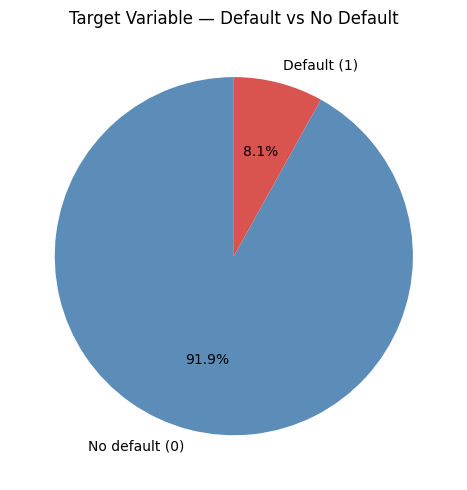

In [33]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    counts,
    labels=['No default (0)', 'Default (1)'],
    autopct='%1.1f%%',
    colors=['#5b8db8', '#d9534f'],
    startangle=90
)
ax.set_title('Target Variable — Default vs No Default')
plt.tight_layout()
plt.show()

The dataset is heavily imbalanced — only about 8% of applicants defaulted. This means when we look at counts alone, the numbers can be misleading. It's better to look at *rates* (what % within each group defaults) rather than raw counts.

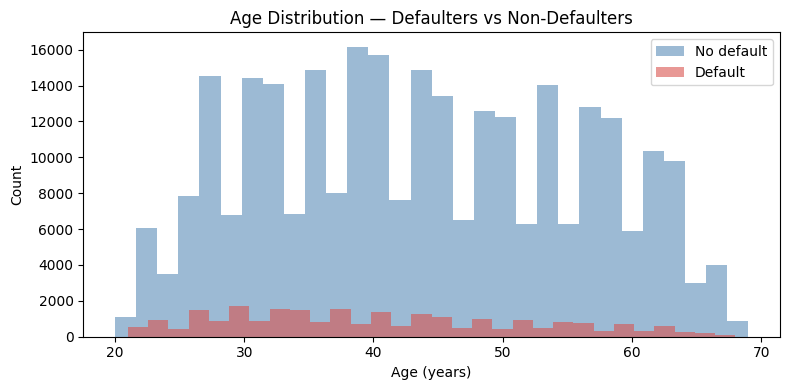

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))

# alpha=0.6 makes the bars slightly transparent
app[app['TARGET'] == 0]['AGE'].plot(kind='hist', bins=30, alpha=0.6,
                                     color='#5b8db8', label='No default', ax=ax)
app[app['TARGET'] == 1]['AGE'].plot(kind='hist', bins=30, alpha=0.6,
                                     color='#d9534f', label='Default', ax=ax)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.set_title('Age Distribution — Defaulters vs Non-Defaulters')
ax.legend()
plt.tight_layout()
plt.show()

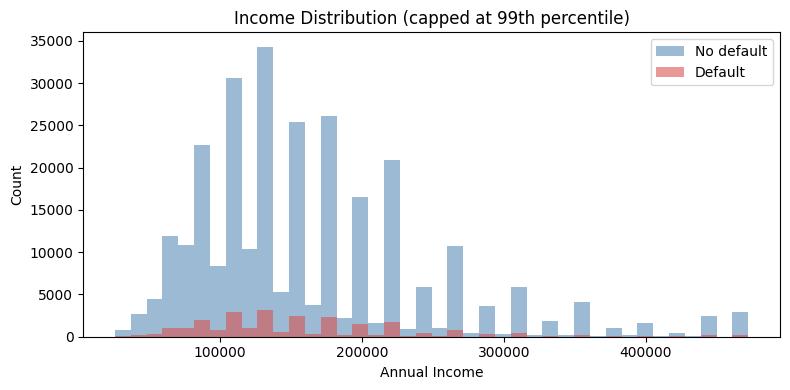

In [35]:
# cap at 99th percentile so a few extreme outliers don't squish the rest of the chart
income_cap = app['AMT_INCOME_TOTAL'].quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 4))

app.loc[app['TARGET'] == 0, 'AMT_INCOME_TOTAL'].clip(upper=income_cap).plot(
    kind='hist', bins=40, alpha=0.6, color='#5b8db8', label='No default', ax=ax)
app.loc[app['TARGET'] == 1, 'AMT_INCOME_TOTAL'].clip(upper=income_cap).plot(
    kind='hist', bins=40, alpha=0.6, color='#d9534f', label='Default', ax=ax)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Count')
ax.set_title('Income Distribution (capped at 99th percentile)')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
cat_vars = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']

for col in cat_vars:
    print(f'\n--- {col} ---')
    print(app[col].value_counts(normalize=True).mul(100).round(1).to_string())


--- NAME_CONTRACT_TYPE ---
NAME_CONTRACT_TYPE
Cash loans         90.5
Revolving loans     9.5

--- CODE_GENDER ---
CODE_GENDER
F      65.8
M      34.2
XNA     0.0

--- NAME_INCOME_TYPE ---
NAME_INCOME_TYPE
Working                 51.6
Commercial associate    23.3
Pensioner               18.0
State servant            7.1
Unemployed               0.0
Student                  0.0
Businessman              0.0
Maternity leave          0.0

--- NAME_EDUCATION_TYPE ---
NAME_EDUCATION_TYPE
Secondary / secondary special    71.0
Higher education                 24.3
Incomplete higher                 3.3
Lower secondary                   1.2
Academic degree                   0.1


---
## 4. What Drives Default?

Now we compare defaulters vs non-defaulters across different variables. For each categorical variable we compute the average default rate per category. For numeric variables we use box plots to compare the distributions.

### 4.1 Categorical Variables

In [37]:
edu_rate = app.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().mul(100).round(1).sort_values(ascending=False)
print('Default rate by education (%):\n', edu_rate)

Default rate by education (%):
 NAME_EDUCATION_TYPE
Lower secondary                  10.9
Secondary / secondary special     8.9
Incomplete higher                 8.5
Higher education                  5.4
Academic degree                   1.8
Name: TARGET, dtype: float64


In [38]:
income_rate = app.groupby('NAME_INCOME_TYPE')['TARGET'].mean().mul(100).round(1).sort_values(ascending=False)
print('Default rate by income type (%):\n', income_rate)

Default rate by income type (%):
 NAME_INCOME_TYPE
Maternity leave         40.0
Unemployed              36.4
Working                  9.6
Commercial associate     7.5
State servant            5.8
Pensioner                5.4
Businessman              0.0
Student                  0.0
Name: TARGET, dtype: float64


In [39]:
housing_rate = app.groupby('NAME_HOUSING_TYPE')['TARGET'].mean().mul(100).round(1).sort_values(ascending=False)
print('Default rate by housing type (%):\n', housing_rate)

Default rate by housing type (%):
 NAME_HOUSING_TYPE
Rented apartment       12.3
With parents           11.7
Municipal apartment     8.5
Co-op apartment         7.9
House / apartment       7.8
Office apartment        6.6
Name: TARGET, dtype: float64


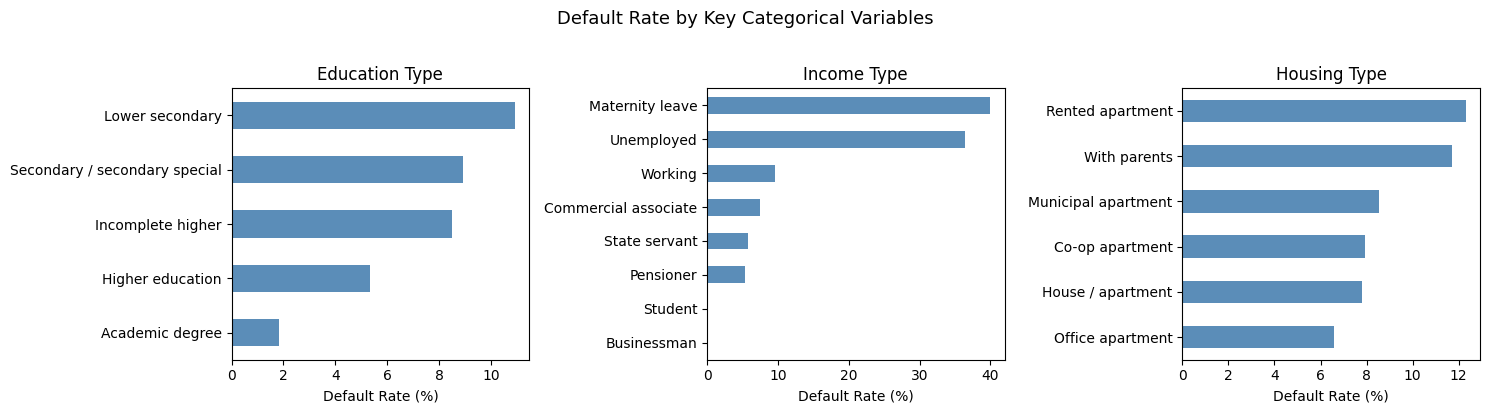

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols   = ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_HOUSING_TYPE']
titles = ['Education Type', 'Income Type', 'Housing Type']

for ax, col, title in zip(axes, cols, titles):
    rates = (app.groupby(col)['TARGET'].mean() * 100).sort_values(ascending=True)
    rates.plot(kind='barh', ax=ax, color='#5b8db8')
    ax.set_title(title)
    ax.set_xlabel('Default Rate (%)')
    ax.set_ylabel('')

plt.suptitle('Default Rate by Key Categorical Variables', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Education and income type show the biggest differences.

- Applicants with only lower secondary education default at nearly 11%, while academic degree holders are barely above 1.8%.

- For income type, unemployed applicants and those on maternity leave stand out with extremely high default rates (over 36%). This makes intuitive sense because if someone has no income, they're much more likely to miss payments.

- For housing, people who rent or live with parents default more often than those who own a house (probably because renters tend to have less financial stability).

### 4.2 Age

In [41]:
app['AGE_GROUP'] = pd.cut(app['AGE'], bins=[20, 30, 40, 50, 60, 70],
                           labels=['20s', '30s', '40s', '50s', '60s'])

age_default = app.groupby('AGE_GROUP', observed=False)['TARGET'].mean() * 100
print('Default rate by age group (%):\n', age_default.round(1))

Default rate by age group (%):
 AGE_GROUP
20s    11.4
30s     9.3
40s     7.6
50s     5.9
60s     4.9
Name: TARGET, dtype: float64


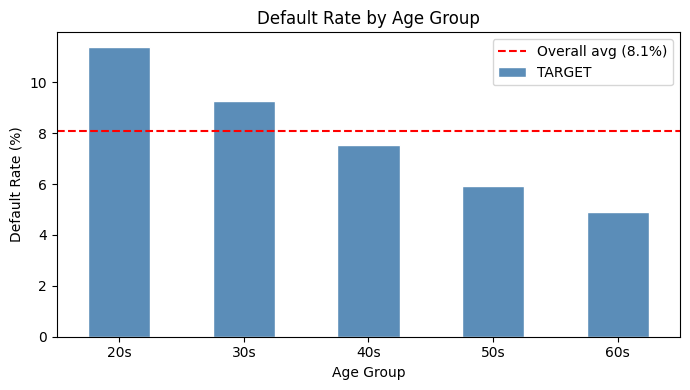

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))

age_default.plot(kind='bar', color='#5b8db8', edgecolor='white', ax=ax)
ax.set_title('Default Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Default Rate (%)')
ax.set_xticklabels(age_default.index, rotation=0)

# reference line at the overall average so we can see who is above/below average
overall_avg = app['TARGET'].mean() * 100
ax.axhline(overall_avg, color='red', linestyle='--', label=f'Overall avg ({overall_avg:.1f}%)')
ax.legend()

plt.tight_layout()
plt.show()

The pattern is obvious. The younger the applicant, the more likely they are to default. People in their 20s default at 11.4%, while people in their 60s default at less than 5%. The red dashed line shows the overall average of 8.1%.

### 4.3 Numeric Variables

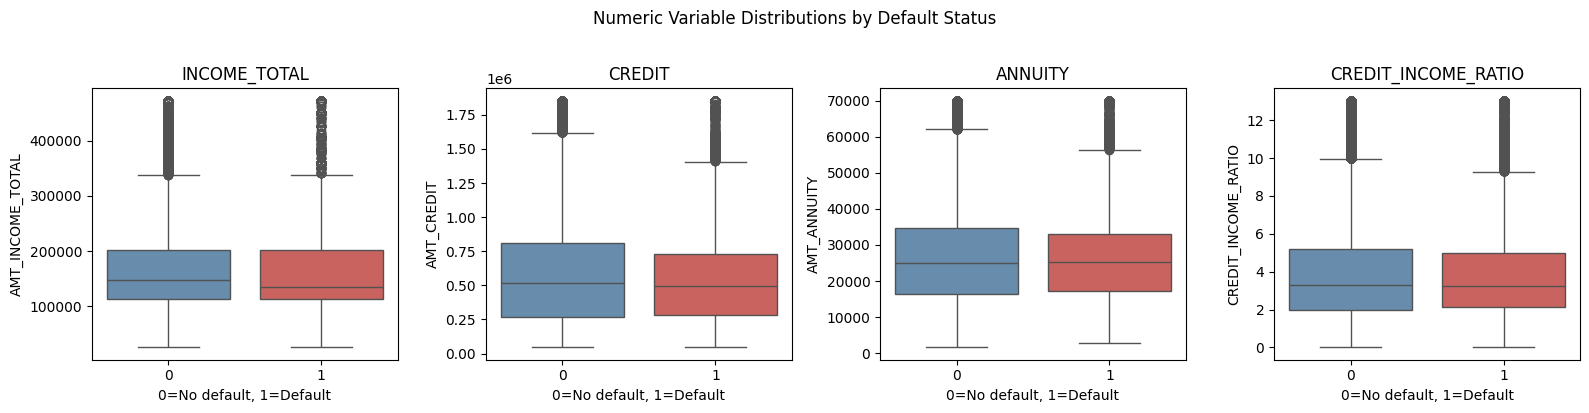

In [43]:
numeric_vars = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_INCOME_RATIO']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, numeric_vars):
    # cap at 99th percentile to avoid outliers collapsing the boxes
    cap = app[col].quantile(0.99)
    plot_data = app[[col, 'TARGET']].copy()
    plot_data[col] = plot_data[col].clip(upper=cap)

    sns.boxplot(x='TARGET', y=col, data=plot_data, ax=ax,
                palette={0: '#5b8db8', 1: '#d9534f'},
                hue='TARGET', legend=False)
    ax.set_title(col.replace('AMT_', ''))
    ax.set_xlabel('0=No default, 1=Default')

plt.suptitle('Numeric Variable Distributions by Default Status', y=1.02)
plt.tight_layout()
plt.show()

In [44]:
comparison = app.groupby('TARGET')[numeric_vars].mean().round(0)
comparison.index = ['No Default', 'Default']
comparison

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_INCOME_RATIO
No Default,169078.0,602648.0,27164.0,4.0
Default,165612.0,557779.0,26482.0,4.0


Defaulters tend to have slightly lower income and take out smaller loans on average. The most interesting variable is `CREDIT_INCOME_RATIO` — defaulters tend to borrow more relative to what they earn. That's an intuitive risk signal: if your loan is large compared to your income, it's harder to keep up with payments.

### 4.4 Region Rating

In [45]:
# REGION_RATING_CLIENT: 1 = best area, 3 = worst area
region_rate = app.groupby('REGION_RATING_CLIENT')['TARGET'].mean() * 100
print('Default rate by region rating (%):\n', region_rate.round(1))

Default rate by region rating (%):
 REGION_RATING_CLIENT
1     4.8
2     7.9
3    11.1
Name: TARGET, dtype: float64


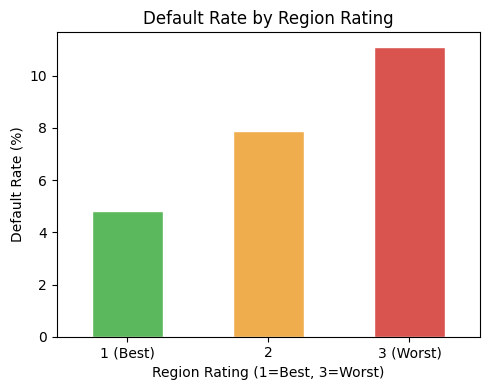

In [46]:
fig, ax = plt.subplots(figsize=(5, 4))

region_rate.plot(kind='bar', color=['#5cb85c', '#f0ad4e', '#d9534f'], edgecolor='white', ax=ax)
ax.set_title('Default Rate by Region Rating')
ax.set_xlabel('Region Rating (1=Best, 3=Worst)')
ax.set_ylabel('Default Rate (%)')
ax.set_xticklabels(['1 (Best)', '2', '3 (Worst)'], rotation=0)

plt.tight_layout()
plt.show()

Applicants from lower-rated regions default significantly more. Region 3 has an 11.1% default rate compared to just 4.8% for Region 1. This could be because lower-rated regions have weaker local economies and fewer job opportunities.

---
## 5. Previous Applications

The previous application dataset tells us what happened when these same applicants applied for loans in the past. Let's see if past behaviour predicts current default risk.

In [47]:
prev_status = prev['NAME_CONTRACT_STATUS'].value_counts()
print(prev_status)
print('\nAs percentages:')
print((prev_status / len(prev) * 100).round(1))

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

As percentages:
NAME_CONTRACT_STATUS
Approved        62.1
Canceled        18.9
Refused         17.4
Unused offer     1.6
Name: count, dtype: float64


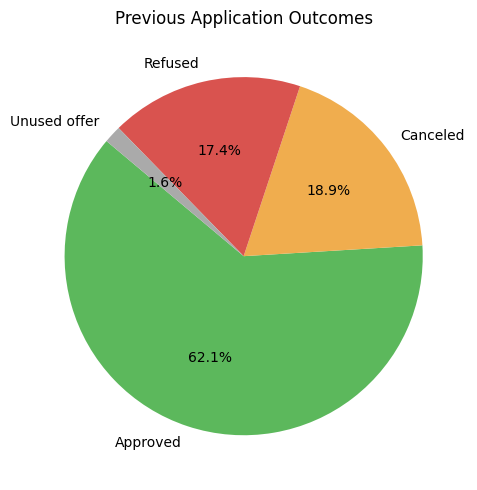

In [48]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(
    prev_status,
    labels=prev_status.index,
    autopct='%1.1f%%',
    colors=['#5cb85c', '#f0ad4e', '#d9534f', '#aaaaaa'],
    startangle=140
)
ax.set_title('Previous Application Outcomes')
plt.tight_layout()
plt.show()

In [49]:
# for each applicant, count how many previous applications they had and how many were refused
prev_counts = prev.groupby('SK_ID_CURR').agg(
    total_prev   = ('SK_ID_PREV', 'count'),
    num_refused  = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    num_approved = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum())
).reset_index()

prev_counts['refusal_rate'] = prev_counts['num_refused'] / prev_counts['total_prev']

prev_counts.head()

,SK_ID_CURR,total_prev,num_refused,num_approved,refusal_rate
0,100001,1,0,1,0.0
1,100002,1,0,1,0.0
2,100003,3,0,3,0.0
3,100004,1,0,1,0.0
4,100005,2,0,1,0.0


In [50]:
# left join keeps all rows from app; applicants with no previous history get NaN, filled with 0
app2 = app.merge(prev_counts, on='SK_ID_CURR', how='left')

fill_cols = ['total_prev', 'num_refused', 'num_approved', 'refusal_rate']
app2[fill_cols] = app2[fill_cols].fillna(0)

print('Merged shape:', app2.shape)

Merged shape: (307511, 89)


In [51]:
app2['refusal_group'] = pd.cut(
    app2['refusal_rate'],
    bins=[-0.01, 0, 0.33, 0.66, 1.0],
    labels=['None', 'Low (0–33%)', 'Medium (33–66%)', 'High (66–100%)']
)

refusal_default = app2.groupby('refusal_group', observed=False)['TARGET'].mean() * 100
print('Default rate by refusal group (%):\n', refusal_default.round(1))

Default rate by refusal group (%):
 refusal_group
None                7.0
Low (0–33%)         8.4
Medium (33–66%)    12.0
High (66–100%)     16.1
Name: TARGET, dtype: float64


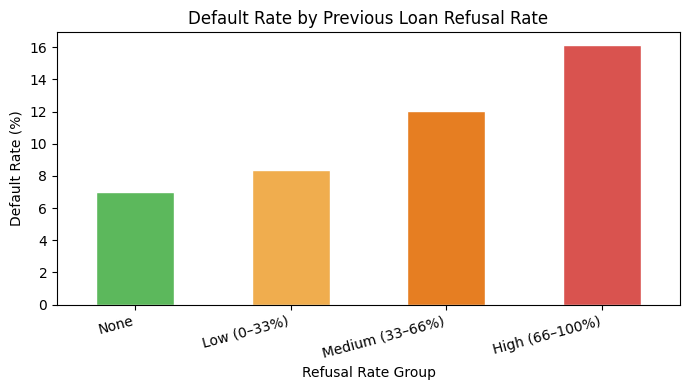

In [52]:
fig, ax = plt.subplots(figsize=(7, 4))

refusal_default.plot(kind='bar',
                     color=['#5cb85c', '#f0ad4e', '#e67e22', '#d9534f'],
                     edgecolor='white', ax=ax)

ax.set_title('Default Rate by Previous Loan Refusal Rate')
ax.set_xlabel('Refusal Rate Group')
ax.set_ylabel('Default Rate (%)')
ax.set_xticklabels(refusal_default.index, rotation=15, ha='right')

plt.tight_layout()
plt.show()

In [53]:
# .map() replaces True/False with readable labels
app2['applicant_type'] = (app2['total_prev'] > 0).map(
    {True: 'Has previous apps', False: 'First-time applicant'}
)

first_time_rate = app2.groupby('applicant_type')['TARGET'].mean() * 100
print('Default rate by applicant type (%):\n', first_time_rate.round(1))

Default rate by applicant type (%):
 applicant_type
First-time applicant    6.0
Has previous apps       8.2
Name: TARGET, dtype: float64


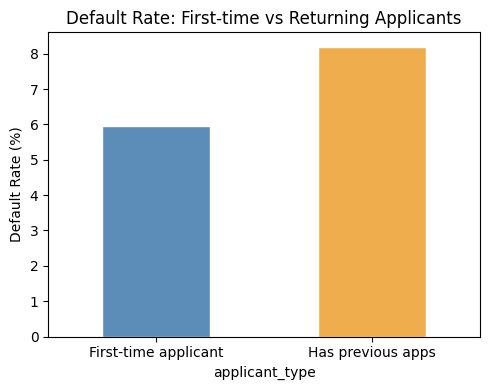

In [54]:
fig, ax = plt.subplots(figsize=(5, 4))

first_time_rate.plot(kind='bar', color=['#5b8db8', '#f0ad4e'], edgecolor='white', ax=ax)
ax.set_title('Default Rate: First-time vs Returning Applicants')
ax.set_ylabel('Default Rate (%)')
ax.set_xticklabels(first_time_rate.index, rotation=0)

plt.tight_layout()
plt.show()

Two things stand out here:

1. **First-time applicants actually default less** than people with previous applications. This might seem surprising, but returning applicants who have been refused before pull the average up.

2. **Refusal rate is a strong predictor.** Applicants who had most of their previous applications refused (66–100% refusal rate) default at well over double the rate of those with no prior refusals. If previous lenders said no, it was probably for good reason.

---
## 6. Summary

After analyzing the two datasets, we found these patterns:

**High-risk applicants are usually:**
- Unemployed or on maternity leave (default rate 36–40%)
- Young applicants in their 20s (11.4%)
- Lower secondary education (10.9%)
- Living in rented apartments or with parents (12.3%)
- High proportion of previous loan refusals (15%+)
- From Region 3, the worst-rated areas (11.1%)

**Safest applicant profiles are usually:**
- Pensioners and state servants (~5–6%)
- Applicants in their 60s (4.9%)
- Academic degree holders (1.8%)
- No history of previous refusals
- From Region 1, the best-rated areas (4.8%)

**Credit-to-income ratio** is also a useful signal where defaulters tend to borrow more relative to their income.

The company should look at a combination of employment status, age, education, housing, region, and past application history when evaluating new applicants.

No single variable tells the full story, but together they give a much clearer picture of default risk!